In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = 'medeley_dataset.csv'
df = pd.read_csv(file_path)

### Kiểm tra dataset
#### Kết luận
Cần encode các field dạng string: IP, functionTrigger, timestamp, vmcategory

In [2]:
# Kiểm tra tổng số lượng giá trị bị thiếu (NaN/Null) ở mỗi cột
print(df.isnull().sum())

Id                           0
IP                           0
bot                          0
FunctionId                   0
functionTrigger              0
timestamp                    0
SubmitTime                   0
RTT                          0
InvocationDelay              0
ResponseDelay                0
FunctionDuration             0
ActiveFunctionsAtRequest     0
ActiveFunctionsAtResponse    0
maxcpu                       0
avgcpu                       0
p95maxcpu                    0
vmcategory                   0
vmcorecountbucket            0
vmmemorybucket               0
dtype: int64


In [3]:
# Đếm số dòng trùng nhau y hệt
print(df.duplicated().sum())

0


In [4]:
# Kiểm tra kiểu dữ liệu của toàn bộ bảng
print(df.dtypes)

Id                             int64
IP                               str
bot                             bool
FunctionId                     int64
functionTrigger                  str
timestamp                        str
SubmitTime                     int64
RTT                            int64
InvocationDelay              float64
ResponseDelay                float64
FunctionDuration             float64
ActiveFunctionsAtRequest       int64
ActiveFunctionsAtResponse      int64
maxcpu                       float64
avgcpu                       float64
p95maxcpu                    float64
vmcategory                       str
vmcorecountbucket              int64
vmmemorybucket               float64
dtype: object


### Exploratory Data Analysis - EDA
Với dữ liệu gốc


[!] THỐNG KÊ CHI TIẾT (NUMERIC):


,count,mean,std,min,25%,50%,75%,max,skew,unique
Id,187087.0,93543.000000,54007.509243,0.000000,46771.500000,93543.000000,140314.500000,187086.000000,1.389827e-16,187087
FunctionId,187087.0,28.592569,13.777358,2.000000,17.000000,30.000000,40.000000,50.000000,-2.543958e-01,45
SubmitTime,187087.0,85.841250,11.968575,71.000000,75.000000,79.000000,98.000000,102.000000,1.279681e-01,18
RTT,187087.0,2494.167083,286.236688,1373.000000,2344.000000,2476.000000,2593.000000,3019.000000,-1.134550e+00,37
InvocationDelay,187087.0,1239.287586,299.874337,170.746338,1060.574707,1205.249512,1388.304443,1800.190674,-6.551022e-01,45
ResponseDelay,187087.0,165.658396,42.838260,117.803711,134.759521,145.178711,203.505127,247.116455,6.201878e-01,45
FunctionDuration,187087.0,1089.373666,62.326101,1031.168938,1059.582233,1074.904203,1099.621534,1437.139511,4.379042e+00,45
ActiveFunctionsAtRequest,187087.0,28.592569,13.777358,2.000000,17.000000,30.000000,40.000000,50.000000,-2.543958e-01,45
ActiveFunctionsAtResponse,187087.0,996.465741,3.010734,988.000000,994.000000,998.000000,999.000000,999.000000,-1.000546e+00,9
maxcpu,187087.0,97.050470,5.018163,78.776399,96.017207,99.356190,99.566656,100.000000,-2.481333e+00,43


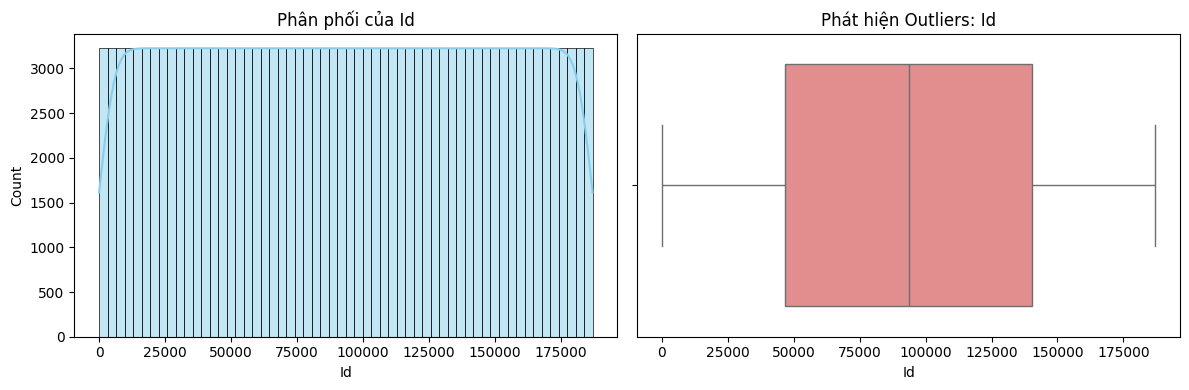

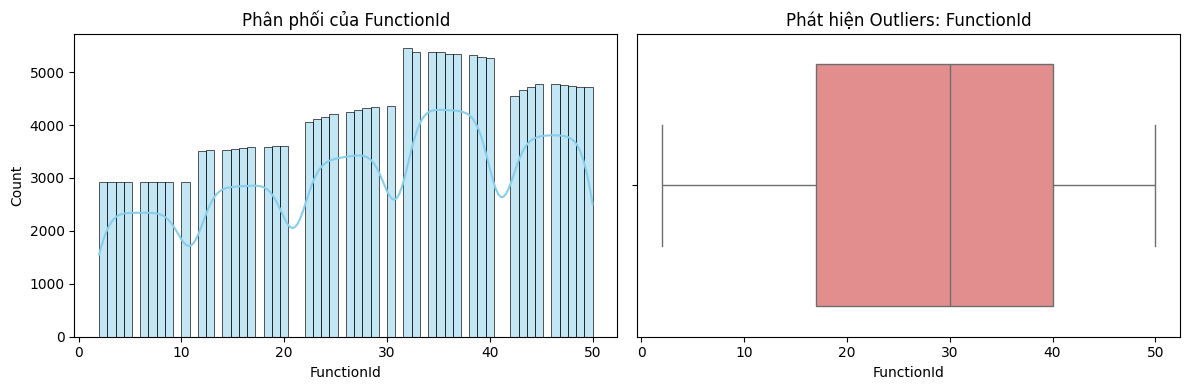

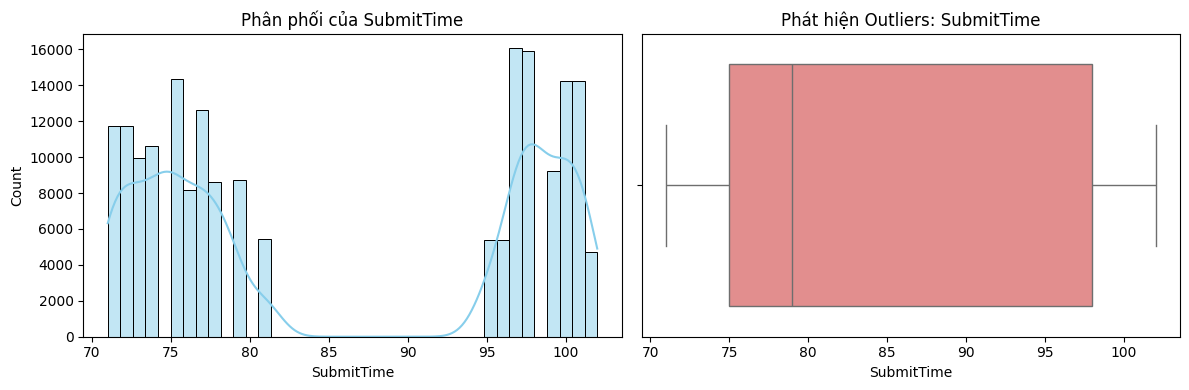

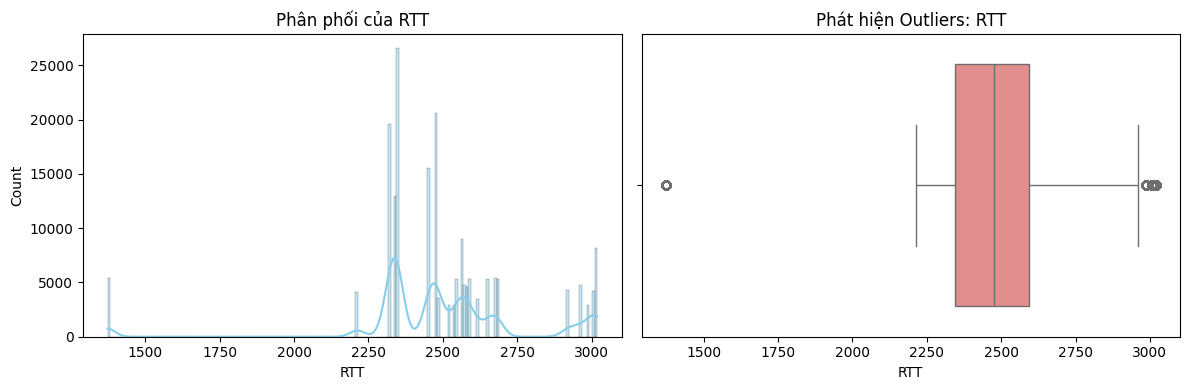

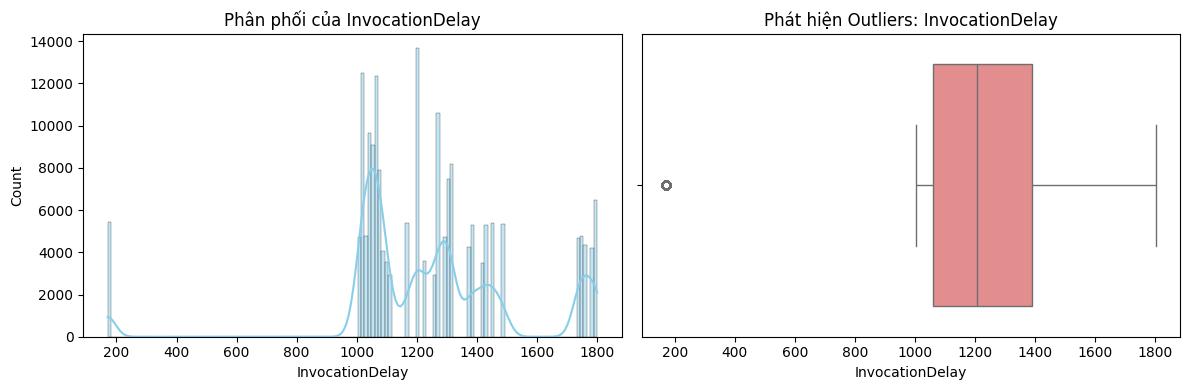

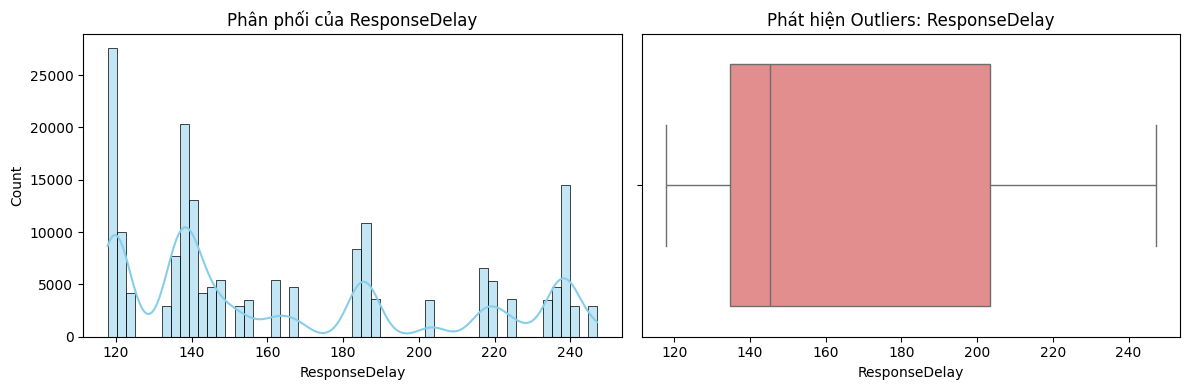

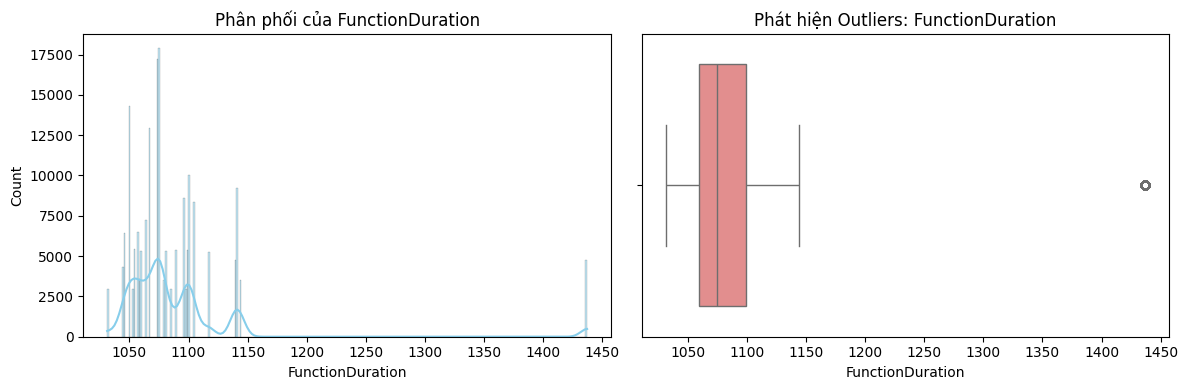

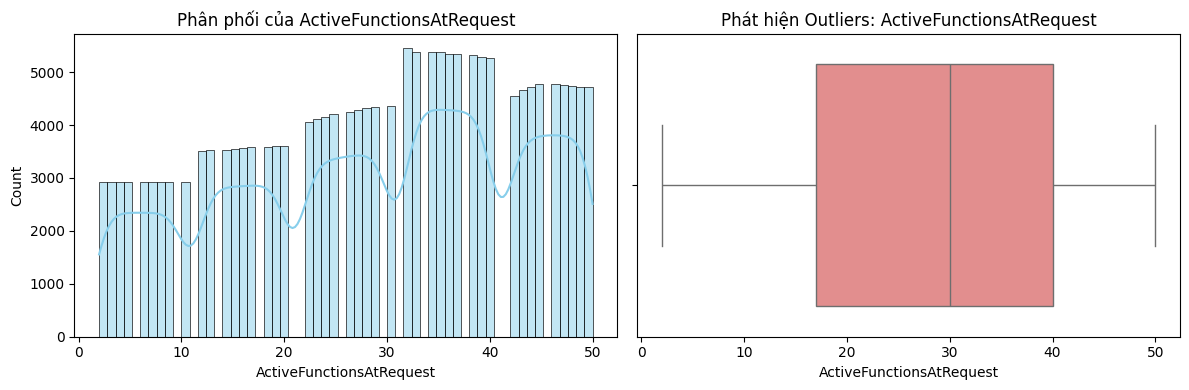

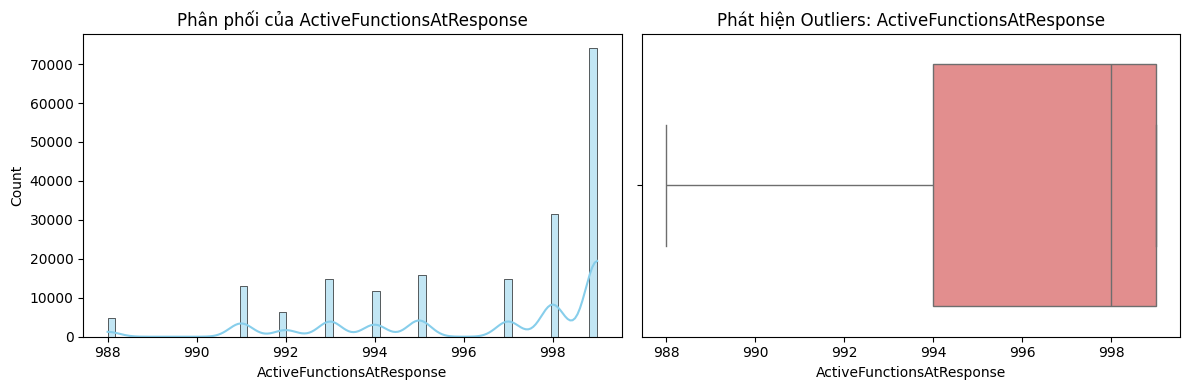

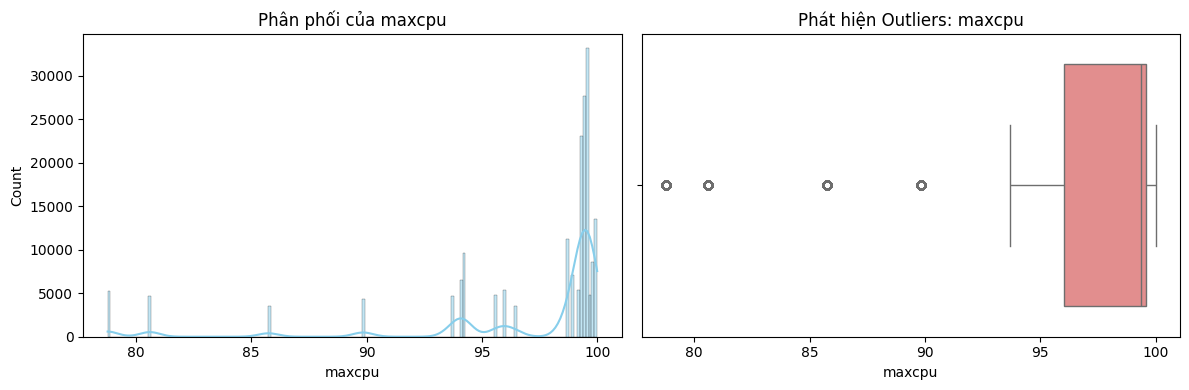

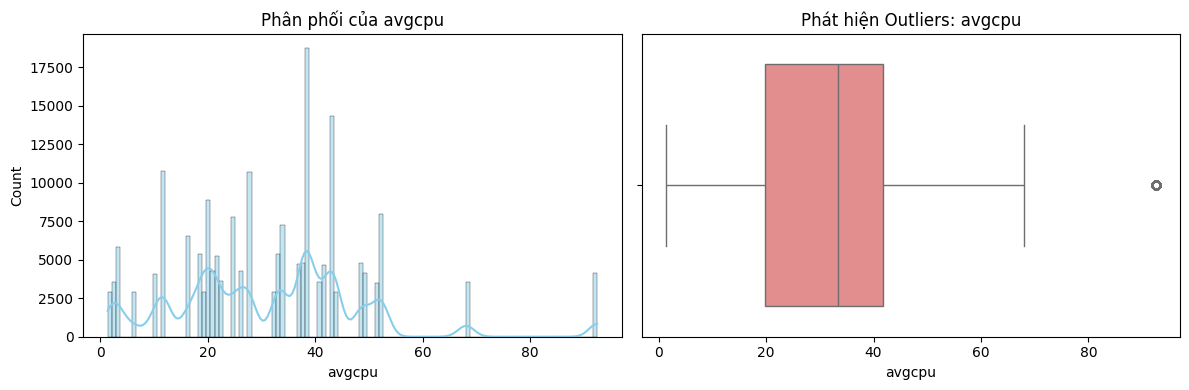

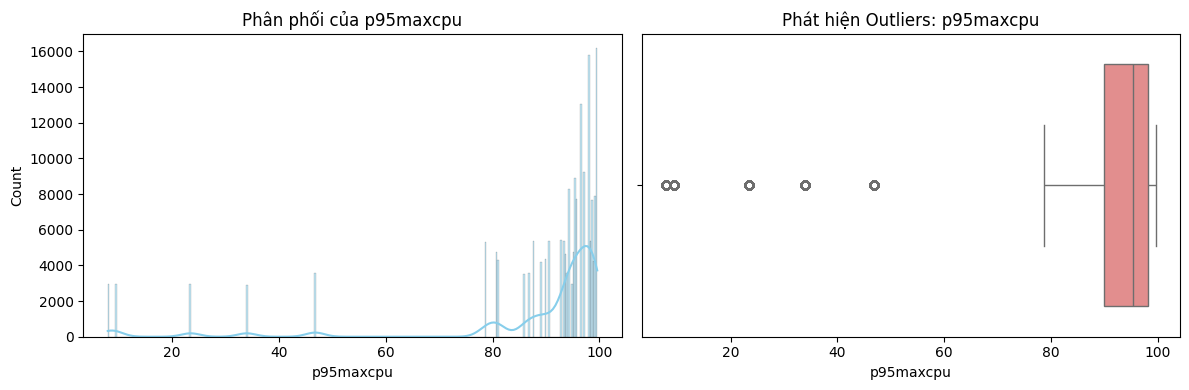

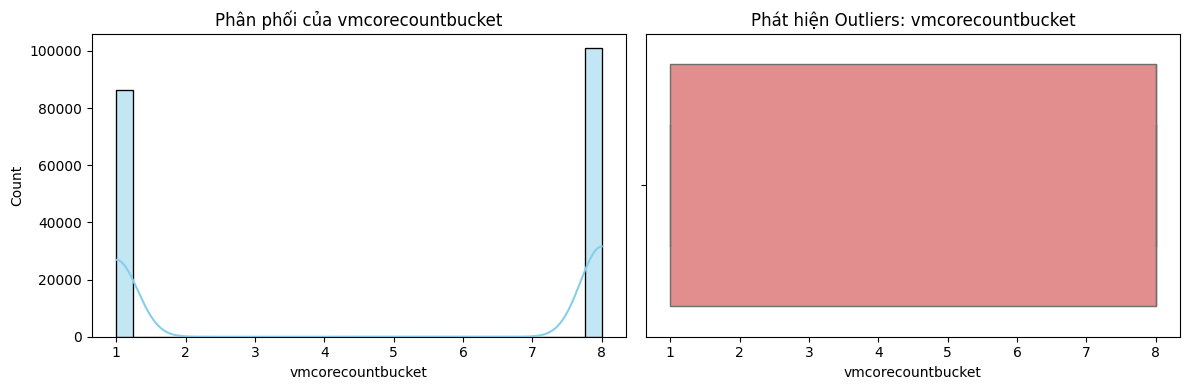

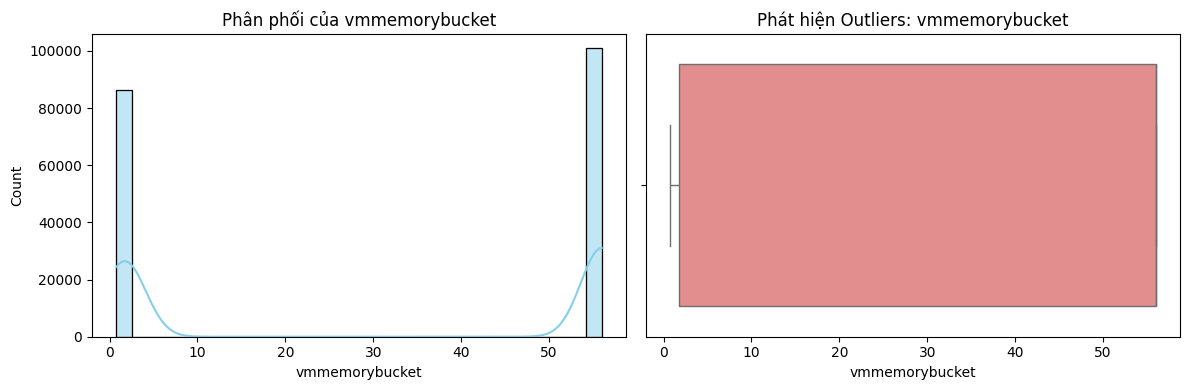

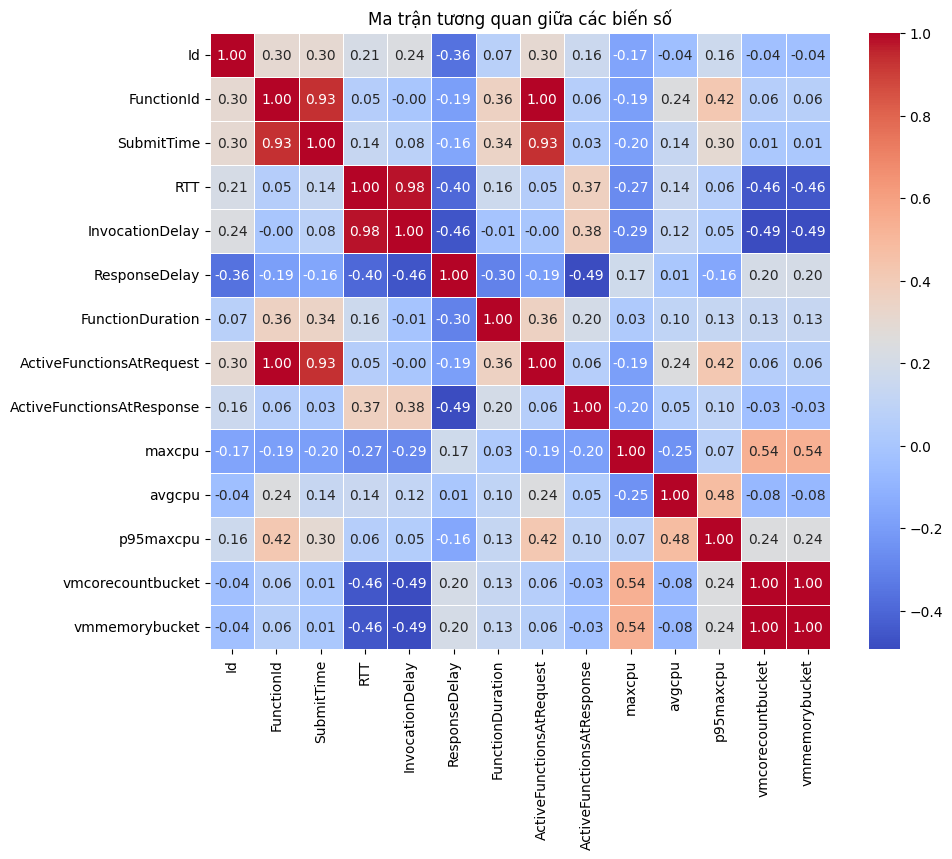

In [5]:
def comprehensive_eda(df):
    # Lọc cột số và cột chữ
    num_cols = df.select_dtypes(include=['number']).columns
    cat_cols = df.select_dtypes(include=['object', 'category', 'str']).columns
    # 1. Thống kê chi tiết cho cột số
    print("\n[!] THỐNG KÊ CHI TIẾT (NUMERIC):")
    desc = df[num_cols].describe().T
    # Thêm độ xiên (Skewness) để xem dữ liệu có bị lệch không
    desc['skew'] = df[num_cols].skew()
    # Thêm số lượng giá trị Unique
    desc['unique'] = df[num_cols].nunique()
    display(desc)

    # 2. TRỰC QUAN HÓA (VISUALIZATION)
    # A. Biểu đồ phân phối & Boxplot (để tìm Outliers)
    for col in num_cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        # Histogram
        sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue')
        axes[0].set_title(f'Phân phối của {col}')
        # Boxplot
        sns.boxplot(x=df[col], ax=axes[1], color='lightcoral')
        axes[1].set_title(f'Phát hiện Outliers: {col}')
        plt.tight_layout()
        plt.show()
    # B. Ma trận tương quan (Heatmap)
    if len(num_cols) > 1:
        plt.figure(figsize=(10, 8))
        correlation_matrix = df[num_cols].corr()
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
        plt.title("Ma trận tương quan giữa các biến số")
        plt.show()

# Chạy hàm EDA
comprehensive_eda(df)

### Xử lý cột IP

                IP  count
0   158.135.184.38   2159
1     190.50.77.86   2155
2    142.45.98.176   2070
3   84.243.175.245   1800
4   227.200.85.209   1800
5    49.174.123.11   1798
6  223.227.178.157   1710
7     138.3.254.87   1710
8    107.248.50.93   1710
9     240.35.183.2   1710


<Axes: xlabel='IP'>

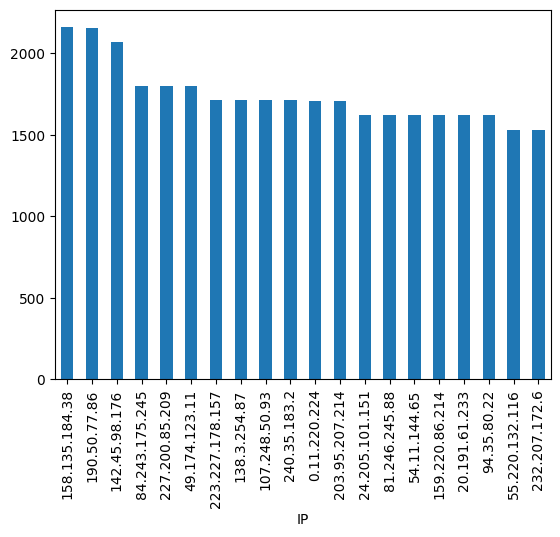

In [6]:
# Đếm số lần xuất hiện của từng IP
ip_counts = df['IP'].value_counts()
# Xem 10 thằng spam căng tay nhất
print(ip_counts.reset_index().head(10))
# Vẽ biểu đồ ra cho dễ nhìn
ip_counts.head(20).plot(kind='bar')

In [7]:
# Tạo cột mới: Ánh xạ (map) tần suất của từng IP vào Dataframe
df['IP_freq'] = df['IP'].map(ip_counts)

# Xem thử kết quả
print(df[['IP', 'IP_freq']].head())


               IP  IP_freq
0   38.57.146.249     1436
1  55.220.132.116     1530
2   141.232.38.48     1350
3  228.143.56.163     1170
4  223.113.21.186     1440


### Xử lý cột functionTrigger

In [8]:
# Dùng .value_counts() để xem các nhãn trong cột
print(df['functionTrigger'].value_counts())

functionTrigger
notification    58199
sql             44176
http            32293
storage         31064
stream          21355
Name: count, dtype: int64


#### Xử lý theo Label Encoding

In [9]:
# Khởi tạo
le = LabelEncoder()
# Fit và biến đổi (Label Encoding) thành cột triggerLabel
df['triggerLabel'] = le.fit_transform(df['functionTrigger'])
# Lấy 10 mẫu ra xem thử
display(df[['functionTrigger', 'triggerLabel']].sample(10))

,functionTrigger,triggerLabel
18412,storage,3
55497,sql,2
83194,http,0
64346,sql,2
10652,notification,1
8039,notification,1
3573,storage,3
186645,http,0
65366,sql,2
40764,storage,3


#### Xử lý theo One-hot Encoding

In [10]:
# Khởi tạo (sparse=False để nó trả về mảng bình thường, handle_unknown='ignore' để chống crash)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# Fit và transform
encoded_data = ohe.fit_transform(df[['functionTrigger']])
# Tạo DataFrame từ kết quả encoded_data
df_ohe = pd.DataFrame(
    encoded_data, 
    columns=ohe.get_feature_names_out(['functionTrigger'])
)
# Hiển thị 10 mẫu ngẫu nhiên cho "đẹp mắt"
display(df_ohe.sample(10))

,functionTrigger_http,functionTrigger_notification,functionTrigger_sql,functionTrigger_storage,functionTrigger_stream
118269,0.0,1.0,0.0,0.0,0.0
24497,0.0,0.0,0.0,0.0,1.0
112407,0.0,1.0,0.0,0.0,0.0
160876,0.0,0.0,1.0,0.0,0.0
96363,0.0,0.0,0.0,1.0,0.0
154201,0.0,0.0,1.0,0.0,0.0
30596,0.0,0.0,0.0,0.0,1.0
119411,0.0,1.0,0.0,0.0,0.0
146236,0.0,1.0,0.0,0.0,0.0
154946,0.0,0.0,1.0,0.0,0.0


### Xử lý cột timestamp: Chuyển sang Epoch

In [11]:
# Chuyển từ chuỗi sang định dạng Datetime (nếu chưa làm)
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601', utc=True)

# Chuyển sang Epoch (đơn vị: Giây)
# Mặc định Pandas trả về nanoseconds, nên mình chia cho 10^9 để lấy giây
df['timestamp'] = df['timestamp'].astype('int64') // 10**9

### Xử lý cột vmcategory

In [12]:
# Đếm số lần xuất hiện của từng loại máy ảo
print(df['vmcategory'].value_counts())

vmcategory
Delay-insensitive    73602
Unkown               57157
Interactive          56328
Name: count, dtype: int64


#### Xử lý theo Label Encoding

In [13]:
# Fit và biến đổi (Label Encoding) thành cột triggerLabel
df['vmcategoryLabel'] = le.fit_transform(df['vmcategory'])
# Lấy 10 mẫu ra xem thử
display(df[['vmcategory', 'vmcategoryLabel']].sample(10))

,vmcategory,vmcategoryLabel
164807,Interactive,1
168068,Unkown,2
64339,Interactive,1
154650,Interactive,1
117087,Delay-insensitive,0
87826,Delay-insensitive,0
124610,Interactive,1
38747,Delay-insensitive,0
14774,Delay-insensitive,0
167675,Unkown,2


#### Xử lý theo One-hot Encoding

In [14]:
# Fit và transform
encoded_data = ohe.fit_transform(df[['vmcategory']])
# Tạo DataFrame từ kết quả encoded_data
df_ohe_2 = pd.DataFrame(
    encoded_data, 
    columns=ohe.get_feature_names_out(['vmcategory'])
)
# Hiển thị 10 mẫu ngẫu nhiên cho "đẹp mắt"
display(df_ohe_2.sample(10))

,vmcategory_Delay-insensitive,vmcategory_Interactive,vmcategory_Unkown
116383,1.0,0.0,0.0
48727,0.0,1.0,0.0
32346,1.0,0.0,0.0
185670,1.0,0.0,0.0
131998,0.0,1.0,0.0
59058,0.0,1.0,0.0
162332,0.0,1.0,0.0
61892,0.0,0.0,1.0
168654,0.0,0.0,1.0
26248,1.0,0.0,0.0


### Kết quả xử lý

In [15]:
# 1. Nối One-hot encoded DataFrames vào df chính
df = pd.concat([df, df_ohe, df_ohe_2], axis=1)

# 2. Xóa các cột chuỗi gốc và Label Encoding
columns_to_drop = ['IP', 'functionTrigger', 'vmcategory', 'triggerLabel', 'vmcategoryLabel']
df = df.drop(columns=columns_to_drop)

# Cuối cùng: Xem lại
print(df.dtypes)

Id                                int64
bot                                bool
FunctionId                        int64
timestamp                         int64
SubmitTime                        int64
RTT                               int64
InvocationDelay                 float64
ResponseDelay                   float64
FunctionDuration                float64
ActiveFunctionsAtRequest          int64
ActiveFunctionsAtResponse         int64
maxcpu                          float64
avgcpu                          float64
p95maxcpu                       float64
vmcorecountbucket                 int64
vmmemorybucket                  float64
IP_freq                           int64
functionTrigger_http            float64
functionTrigger_notification    float64
functionTrigger_sql             float64
functionTrigger_storage         float64
functionTrigger_stream          float64
vmcategory_Delay-insensitive    float64
vmcategory_Interactive          float64
vmcategory_Unkown               float64


### EDA với data đã clean


[!] THỐNG KÊ CHI TIẾT (NUMERIC):


,count,mean,std,min,25%,50%,75%,max,skew,unique
Id,187087.0,9.354300e+04,54007.509243,0.000000e+00,4.677150e+04,9.354300e+04,1.403145e+05,1.870860e+05,1.389827e-16,187087
FunctionId,187087.0,2.859257e+01,13.777358,2.000000e+00,1.700000e+01,3.000000e+01,4.000000e+01,5.000000e+01,-2.543958e-01,45
timestamp,187087.0,1.641084e+06,53.854086,1.640998e+06,1.641006e+06,1.641107e+06,1.641126e+06,1.641146e+06,-6.987758e-01,67
SubmitTime,187087.0,8.584125e+01,11.968575,7.100000e+01,7.500000e+01,7.900000e+01,9.800000e+01,1.020000e+02,1.279681e-01,18
RTT,187087.0,2.494167e+03,286.236688,1.373000e+03,2.344000e+03,2.476000e+03,2.593000e+03,3.019000e+03,-1.134550e+00,37
InvocationDelay,187087.0,1.239288e+03,299.874337,1.707463e+02,1.060575e+03,1.205250e+03,1.388304e+03,1.800191e+03,-6.551022e-01,45
ResponseDelay,187087.0,1.656584e+02,42.838260,1.178037e+02,1.347595e+02,1.451787e+02,2.035051e+02,2.471165e+02,6.201878e-01,45
FunctionDuration,187087.0,1.089374e+03,62.326101,1.031169e+03,1.059582e+03,1.074904e+03,1.099622e+03,1.437140e+03,4.379042e+00,45
ActiveFunctionsAtRequest,187087.0,2.859257e+01,13.777358,2.000000e+00,1.700000e+01,3.000000e+01,4.000000e+01,5.000000e+01,-2.543958e-01,45
ActiveFunctionsAtResponse,187087.0,9.964657e+02,3.010734,9.880000e+02,9.940000e+02,9.980000e+02,9.990000e+02,9.990000e+02,-1.000546e+00,9


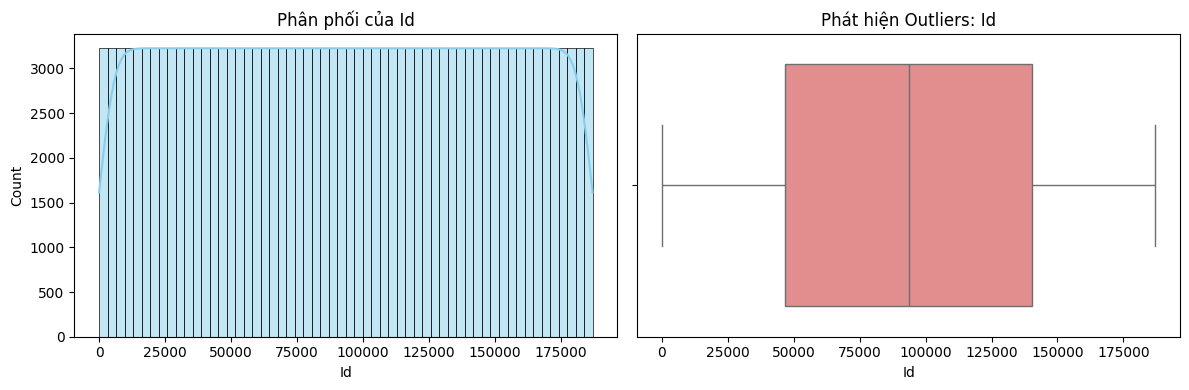

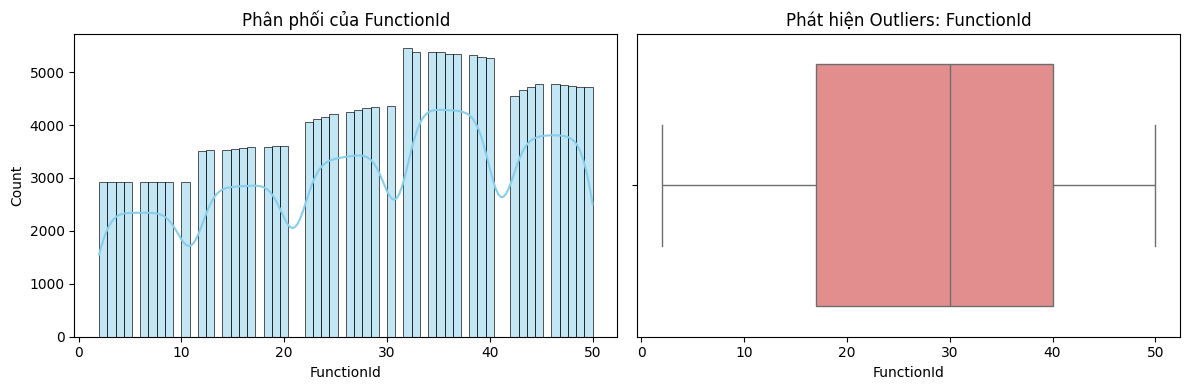

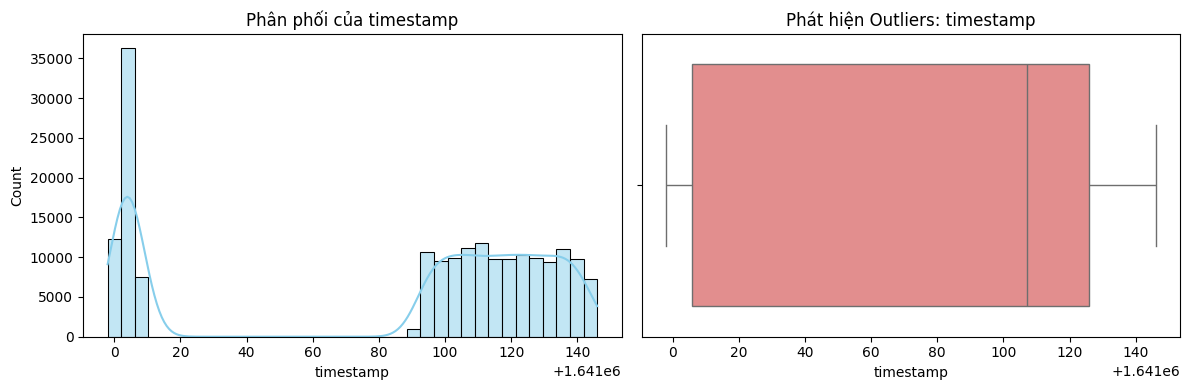

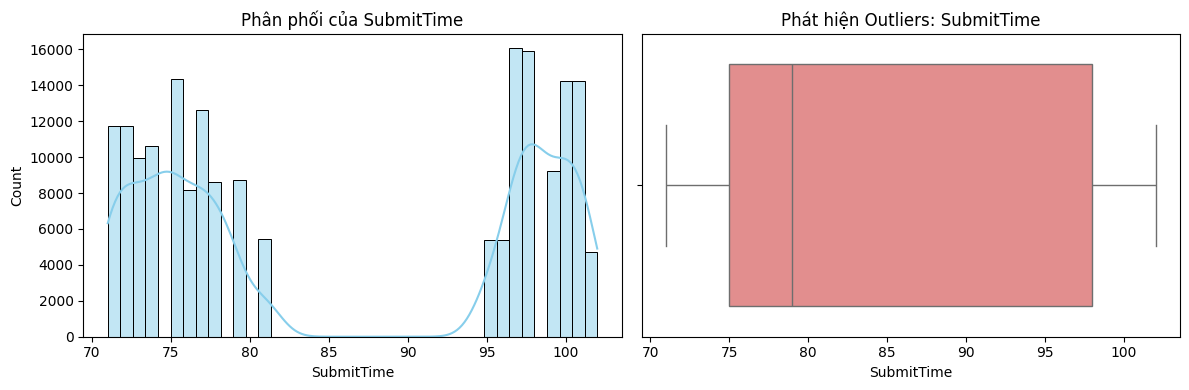

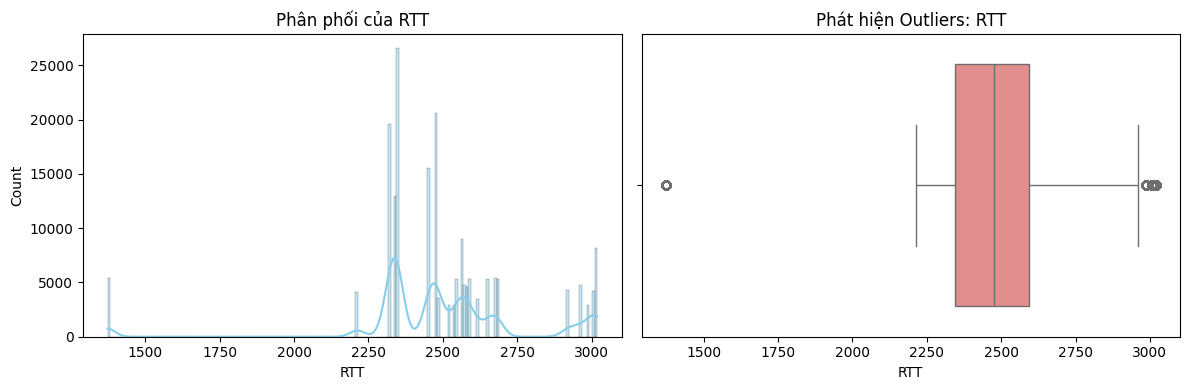

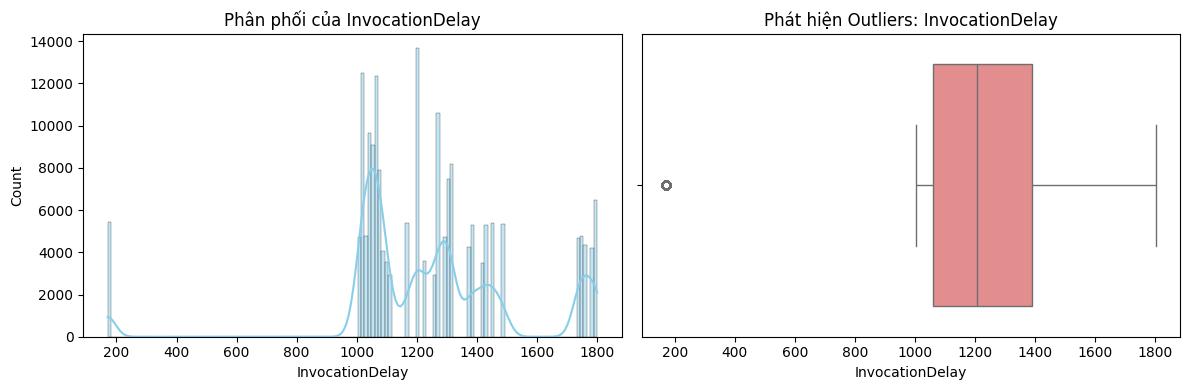

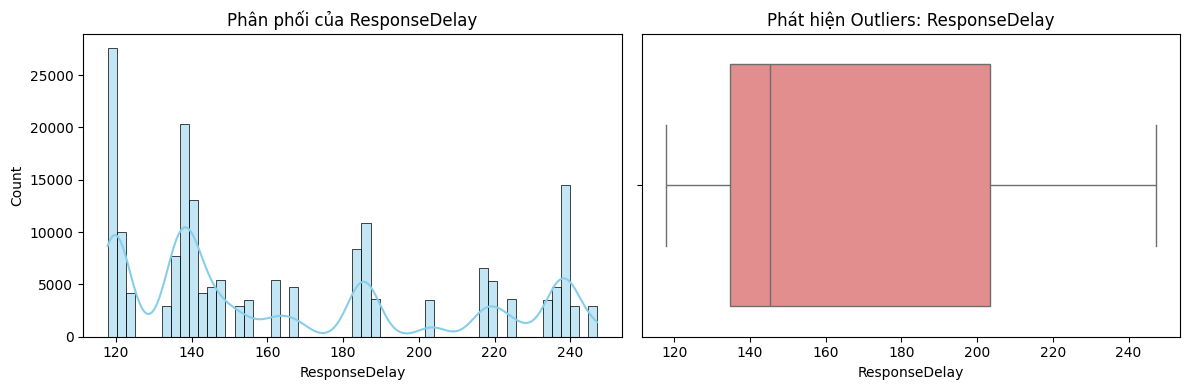

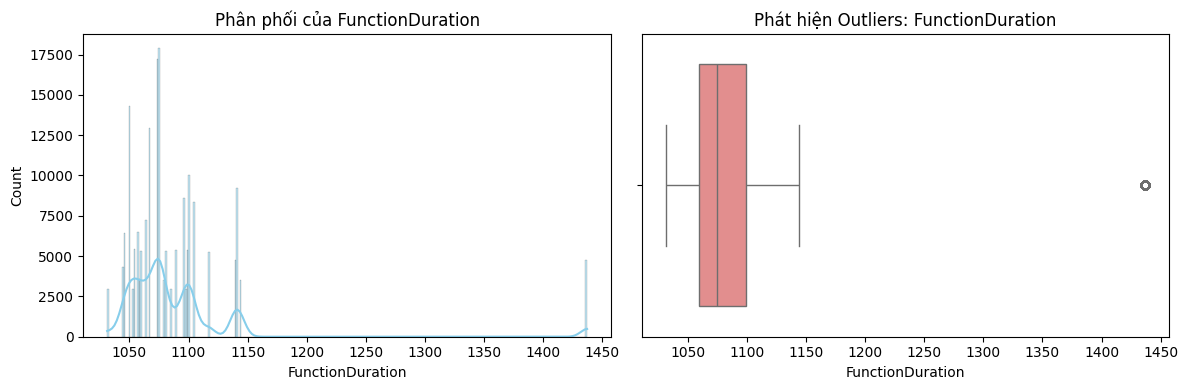

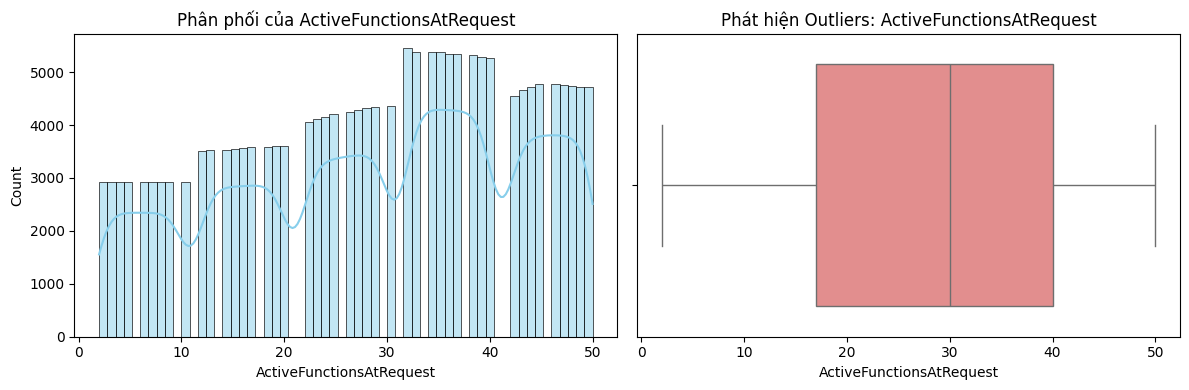

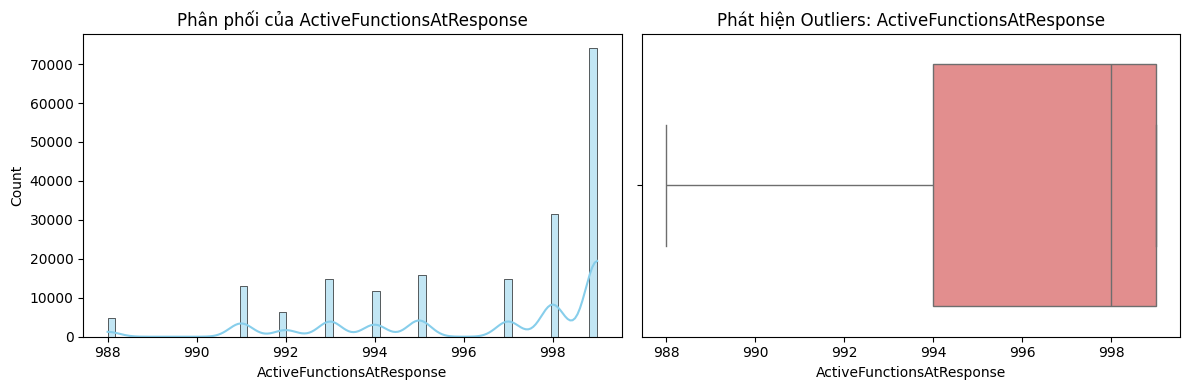

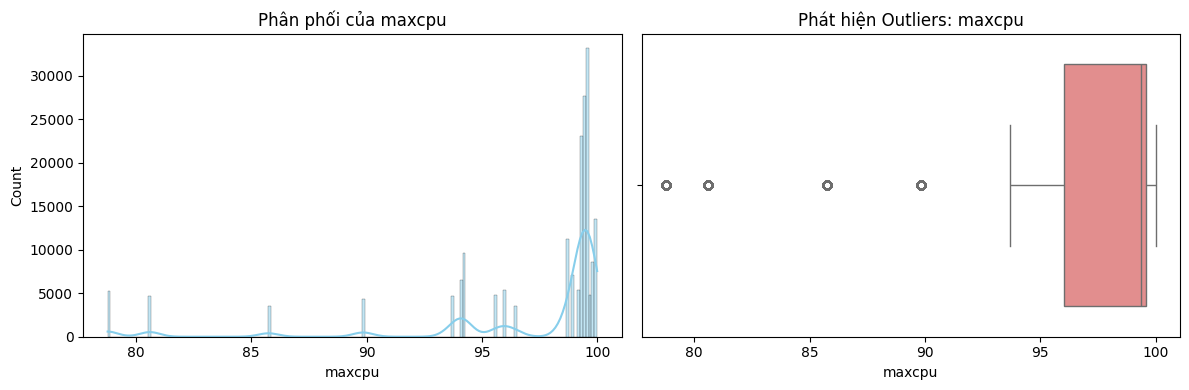

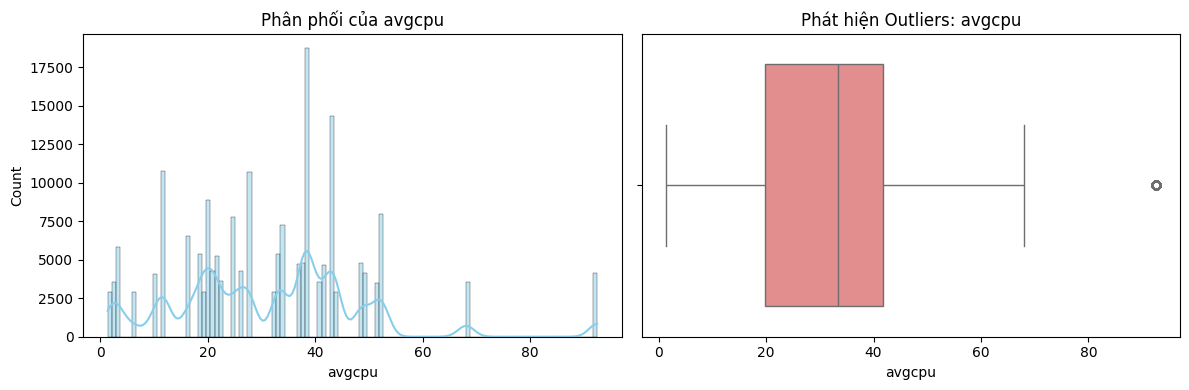

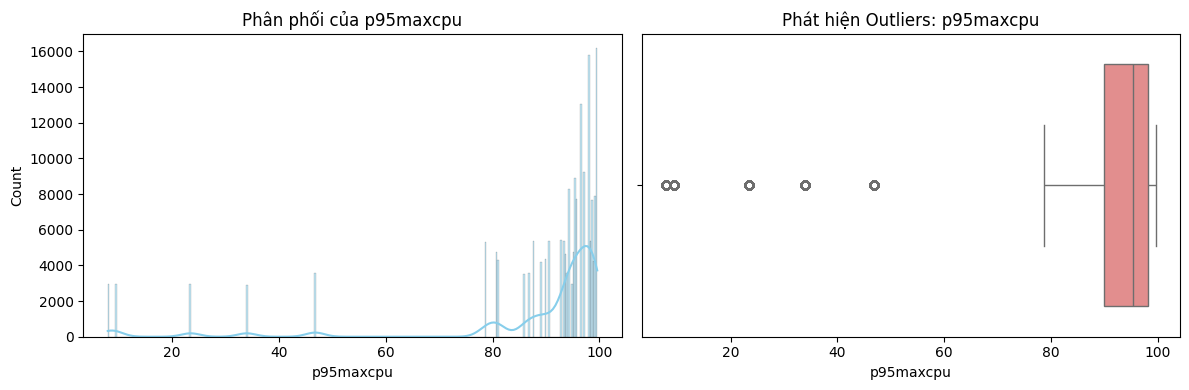

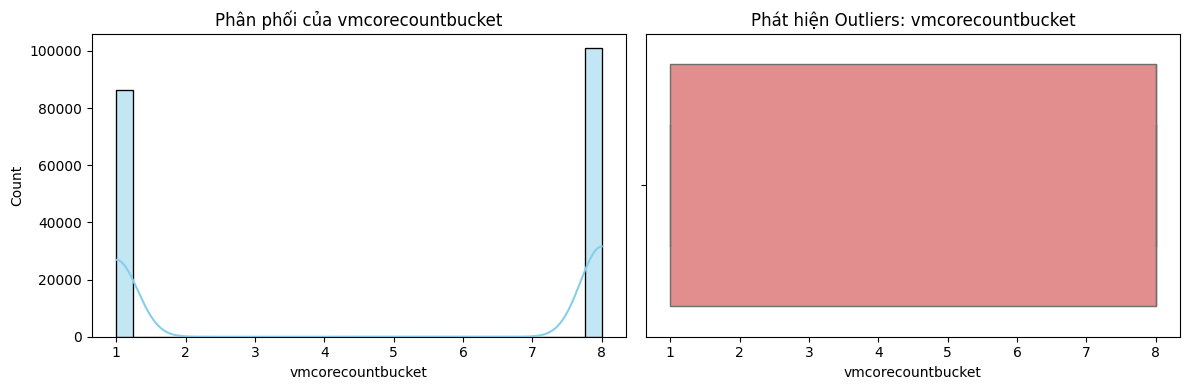

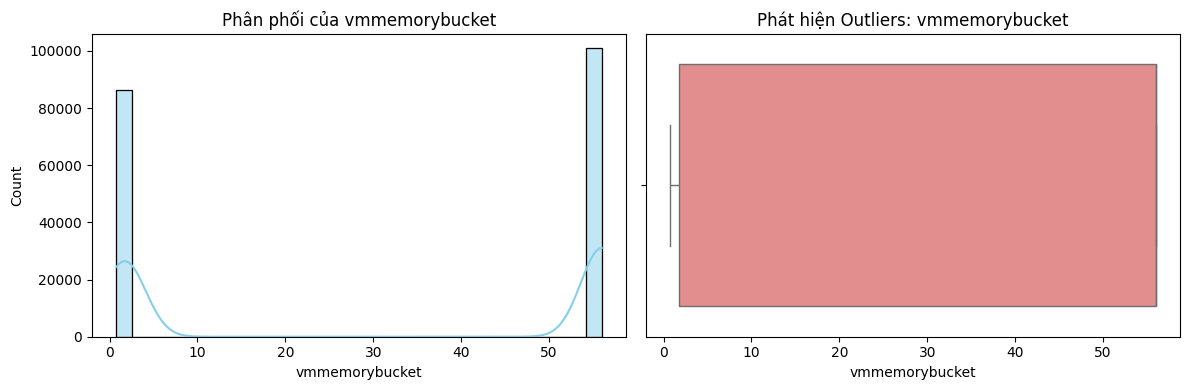

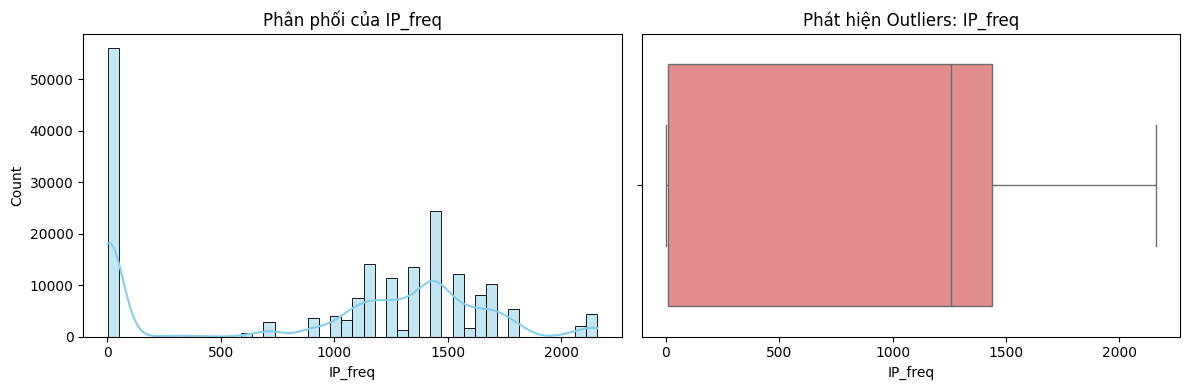

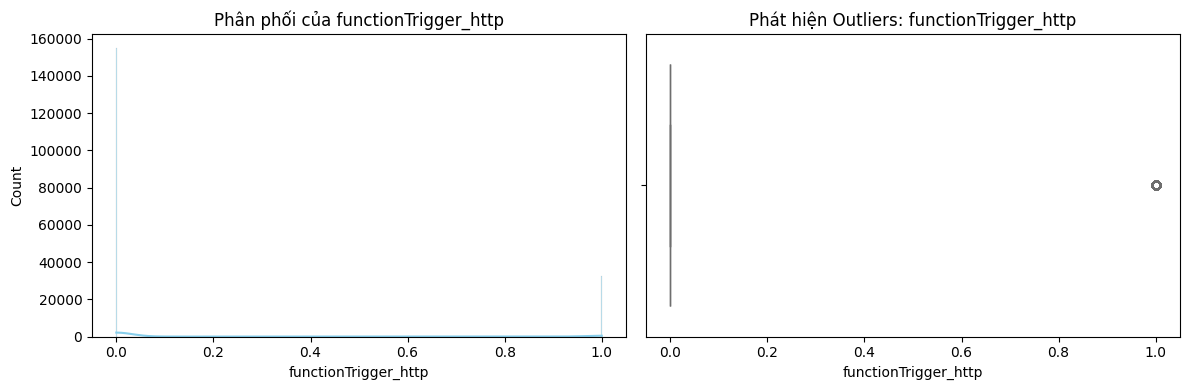

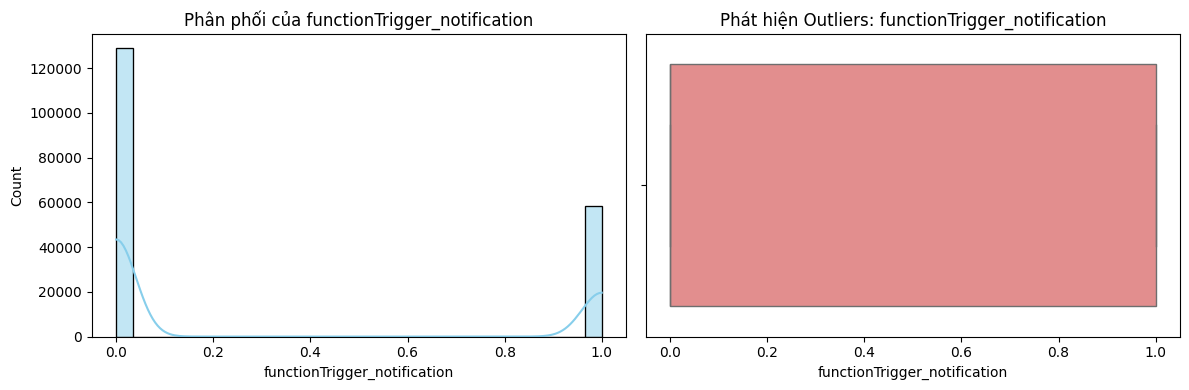

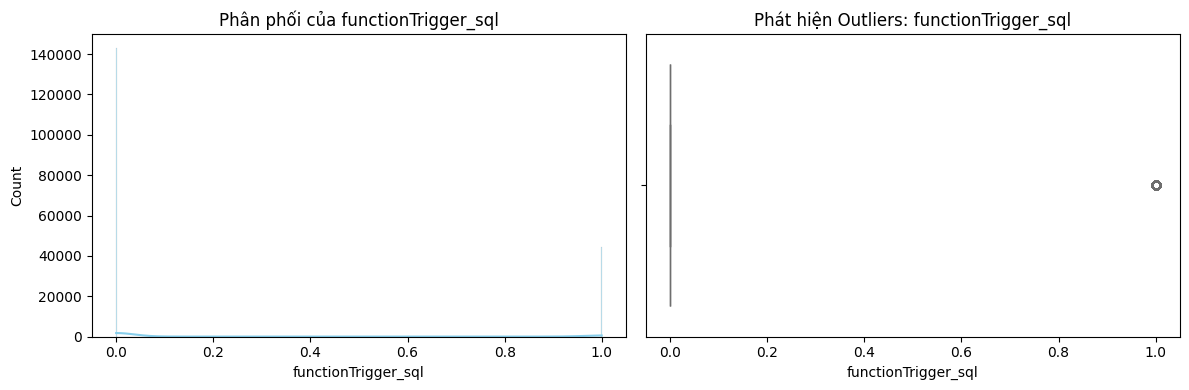

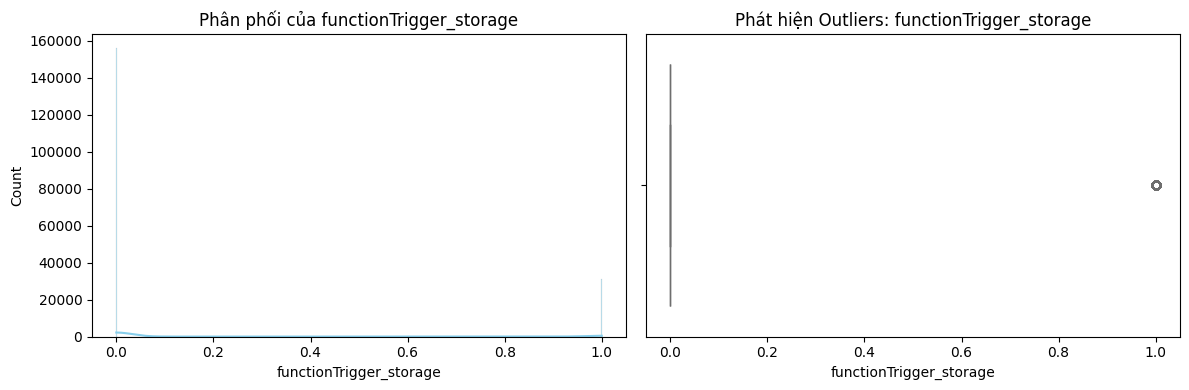

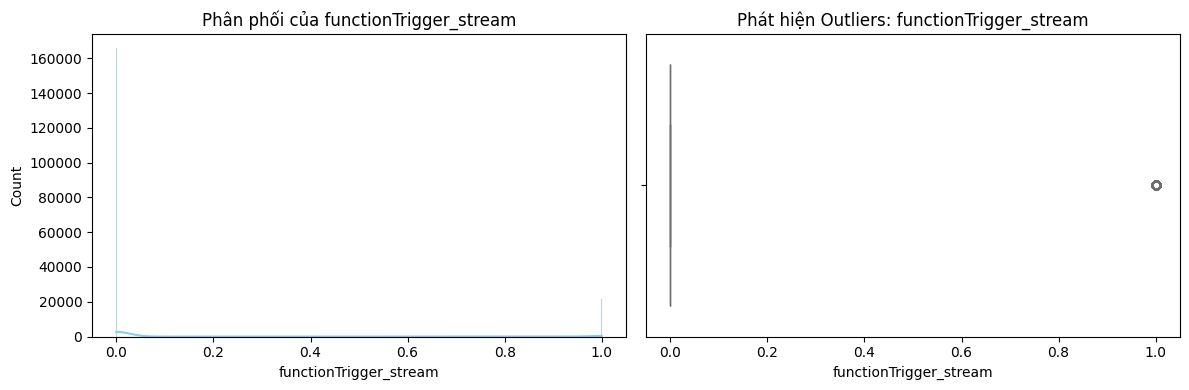

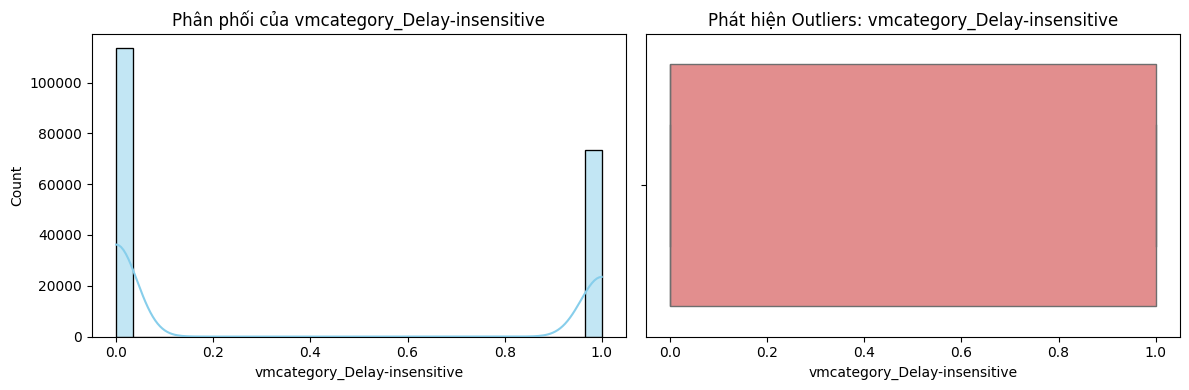

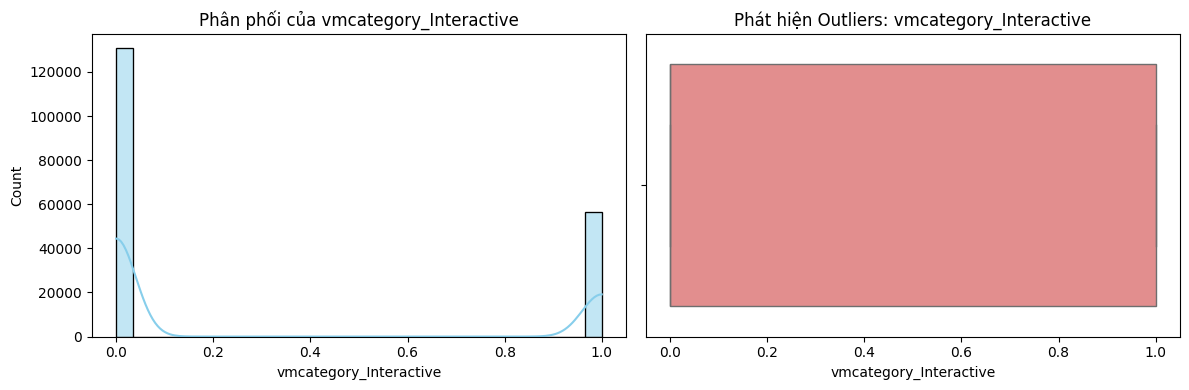

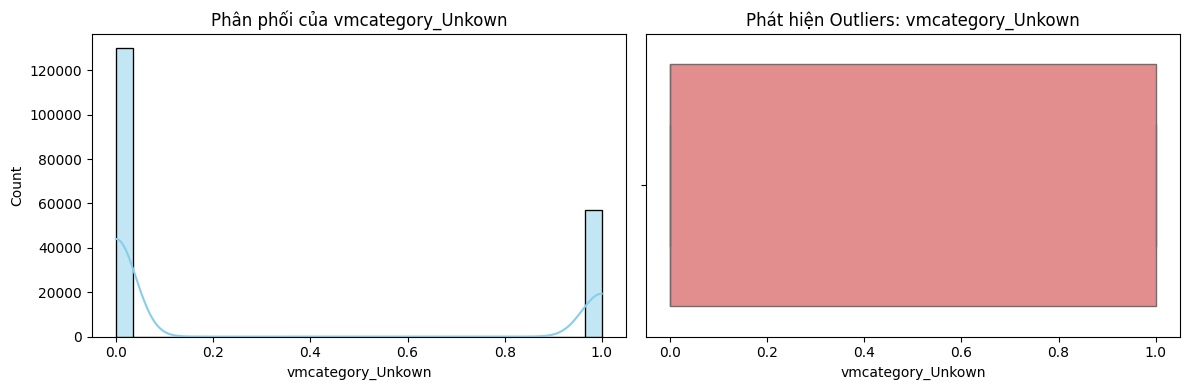

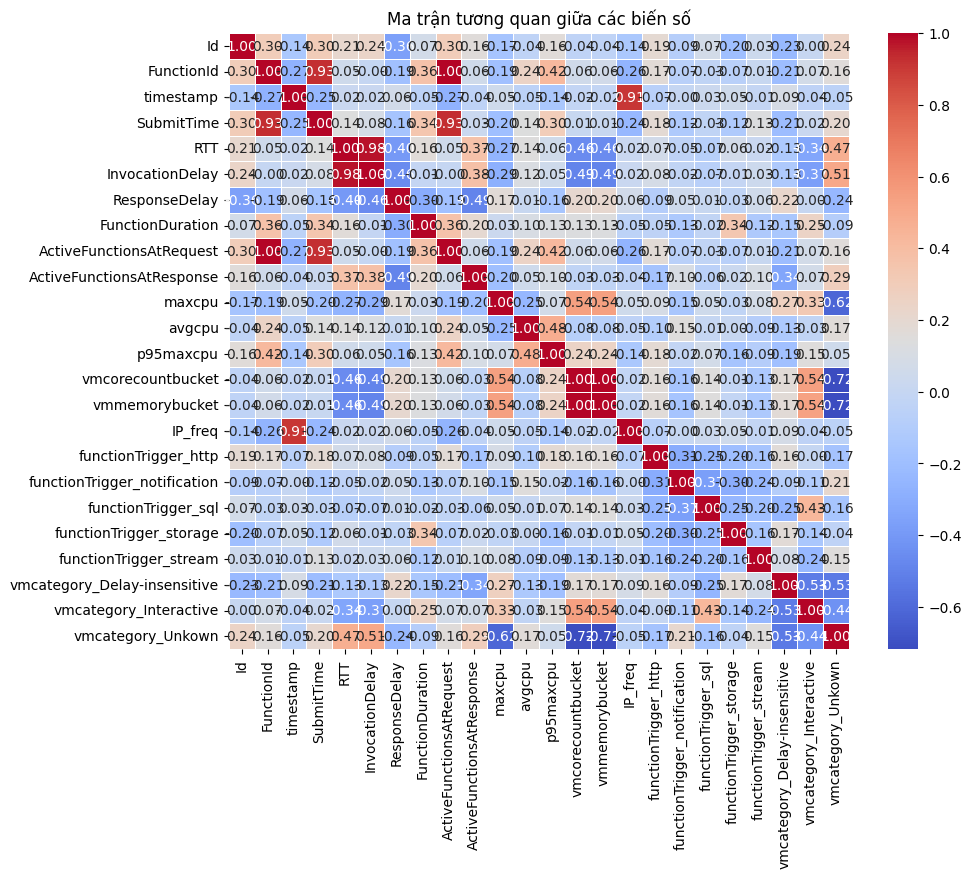

In [16]:
# Chạy hàm EDA
comprehensive_eda(df)